In [ ]:
# NHS A&E Demand Forecasting & Performance Modelling

In [29]:
#installing prophet 
pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ----------- ---------------------------- 3.4/12.1 MB 18.5 MB/s eta 0:00:01
   ------------------------- -------------- 7.6/12.1 MB 19.2 MB/s eta 0:00:01
   -------------------------------------- - 11.5/12.1 MB 19.0 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 17.5 MB/s  0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 14.0 MB/s  0:00:00

   -------- ------------------------------- 1/5 [importlib_resources]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [ho

In [68]:
#Loading the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [ ]:
### 1. Data Loading & Cleaning

In [45]:

# Step 1 — Load both sheets
file_path = "Supplementary-ECDS-Analysis-Time-Series-February-2023-Onwards-ALAW26.xlsx"

#Step 2 Identify the correct header rows , rename the column names, change period to date format and copy 
t1_raw = pd.read_excel(file_path, sheet_name="T1_2 Activity Time Series",header=None)
activity = t1_raw.iloc[15:, [1, 3, 4]].copy()
activity.columns = ['date', 'total_attendances', 'admitted_attendances']
activity = activity.dropna(subset=['date', 'total_attendances'])
activity['date'] = pd.to_datetime(activity['date'])

t2_raw = pd.read_excel(file_path, sheet_name='T1_2 Performance Time Series', header=None)
performance = t2_raw.iloc[16:, [1, 3, 4, 5]].copy()
performance.columns = ['date', 'attendances_over_12hrs', 'denominator_12hr', 'pct_12hr']
performance = performance.dropna(subset=['date', 'attendances_over_12hrs'])
performance['date'] = pd.to_datetime(performance['date'])

# Step 3 — Merge on Date
combined = pd.merge(activity, performance, on='date', how='inner')
combined = combined.sort_values('date').reset_index(drop=True)

# Save
combined.to_csv('combined_ae_data.csv', index=False)


In [46]:
#loading the merged csv into dataframe
df = pd.read_csv('combined_ae_data.csv')

In [ ]:
### 2. Exploratory Data Analysis (EDA)

In [47]:
#Checking the shape
df.shape

(40, 6)

In [48]:
#Checking the first rows
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    40 non-null     object 
 1   total_attendances       40 non-null     int64  
 2   admitted_attendances    40 non-null     int64  
 3   attendances_over_12hrs  40 non-null     int64  
 4   denominator_12hr        40 non-null     int64  
 5   pct_12hr                40 non-null     float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.0+ KB


,date,total_attendances,admitted_attendances,attendances_over_12hrs,denominator_12hr,pct_12hr
0,2023-02-01,1241285,286240,128580,1241285,0.104000
1,2023-03-01,1407215,318425,146920,1407215,0.104000
2,2023-04-01,1268335,295100,103185,1292263,0.079848
3,2023-05-01,1386750,310810,117355,1423920,0.082417
4,2023-06-01,1354540,303775,110331,1405955,0.078474


In [49]:
df.describe()

,total_attendances,admitted_attendances,attendances_over_12hrs,denominator_12hr,pct_12hr
count,4.000000e+01,40.000000,40.000000,4.000000e+01,40.000000
mean,1.410263e+06,327394.925000,144145.375000,1.427697e+06,0.100929
std,7.933646e+04,27779.443172,20722.044888,6.652328e+04,0.013736
min,1.202520e+06,271100.000000,103185.000000,1.241285e+06,0.073681
25%,1.356224e+06,308121.500000,129855.750000,1.393200e+06,0.091772
50%,1.440970e+06,328500.500000,145358.000000,1.431086e+06,0.100974
75%,1.471382e+06,349463.500000,155116.500000,1.478836e+06,0.109652
max,1.532973e+06,378535.000000,193597.000000,1.532973e+06,0.131000


In [50]:
# Parsing the date correctly
df = pd.read_csv('combined_ae_data.csv', parse_dates=['date'])

In [51]:
#Checking for null values
df.isnull().sum()

date                      0
total_attendances         0
admitted_attendances      0
attendances_over_12hrs    0
denominator_12hr          0
pct_12hr                  0
dtype: int64

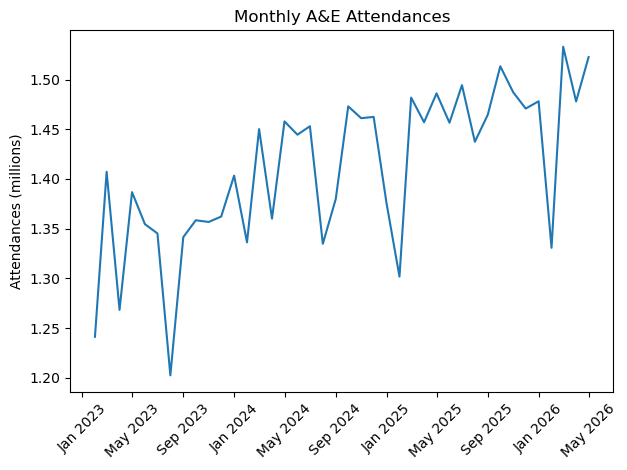

In [52]:
#Visualise trends in attendances, admissions, and 12‑hour breaches  
#- Identify seasonal patterns and operational pressure points  
#- Correlation analysis between demand and performance metrics  

plt.plot(df['date'], df['total_attendances'] / 1_000_000)
plt.title('Monthly A&E Attendances')
plt.ylabel('Attendances (millions)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
df_prophet = df[['date','total_attendances']].rename(columns={'date':'ds', 'total_attendances':'y'})
print(df_prophet.head())

          ds        y
0 2023-02-01  1241285
1 2023-03-01  1407215
2 2023-04-01  1268335
3 2023-05-01  1386750
4 2023-06-01  1354540


In [ ]:
### 3. Forecasting Models
#- Prophet model for Total Attendances and 12 hr Breach 
#- Trend and seasonality decomposition  
#- 12‑month forecast generation  

In [54]:
# Prophet model for Total Attendances
from prophet import Prophet

model = Prophet(yearly_seasonality = True,
                weekly_seasonality=False,
                daily_seasonality=False,
                seasonality_mode='multiplicative',
                interval_width=0.95)

model.fit(df_prophet)
print('Model fitted successfully')

15:08:01 - cmdstanpy - INFO - Chain [1] start processing
15:08:02 - cmdstanpy - INFO - Chain [1] done processing


Model fitted successfully


In [55]:
#Forecasting future months A&E
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

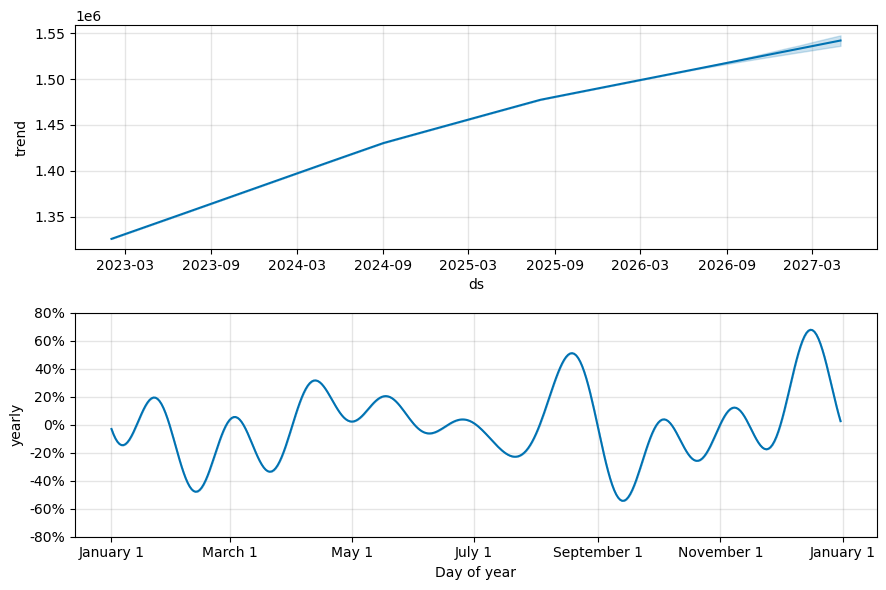

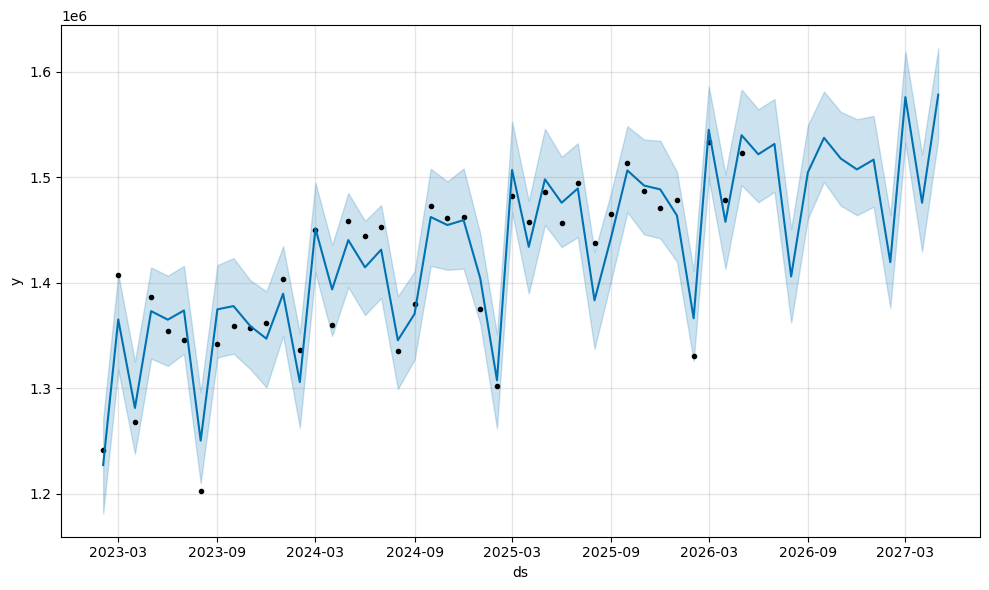

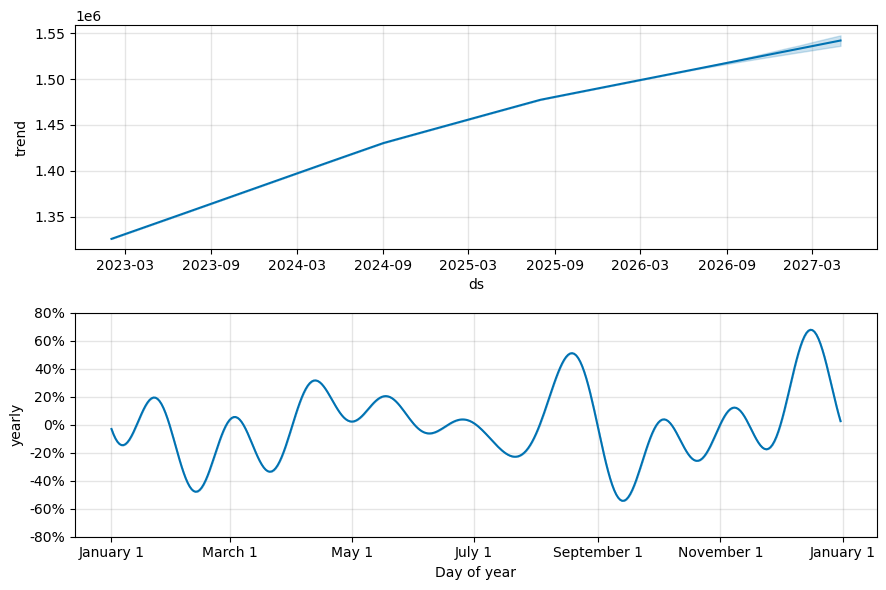

In [56]:
# Plot the model
model.plot(forecast)
model.plot_components(forecast)

In [57]:
# First and last forecast values (historical period only)
first = forecast[forecast['ds'] == df_prophet['ds'].min()]['trend'].values[0]
last  = forecast[forecast['ds'] == df_prophet['ds'].max()]['trend'].values[0]
months = len(df_prophet)

monthly_growth = (last - first) / months
print(f'Average monthly growth: {monthly_growth:,.0f} attendances per month')
print(f'Annual growth rate: {monthly_growth * 12:,.0f} attendances per year')

Average monthly growth: 4,488 attendances per month
Annual growth rate: 53,855 attendances per year


In [62]:
# Evaluating the prophet model 
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(
    model,
    initial='730 days',    # train on first 2 years
    period='90 days',      # re-evaluate every 3 months
    horizon='180 days',    # test how well it predicts 6 months ahead
    parallel='processes'
)

df_perf = performance_metrics(df_cv)

print(f"MAPE: {df_perf['mape'].mean()*100:.1f}%")
print(f"MAE:  {df_perf['mae'].mean():,.0f} attendances")

MAPE: 6.2%
MAE:  90,142 attendances


In [59]:
df_breach = df[['date', 'pct_12hr']].rename(columns={'date':'ds','pct_12hr':'y'})
print(df_breach.head())


          ds         y
0 2023-02-01  0.104000
1 2023-03-01  0.104000
2 2023-04-01  0.079848
3 2023-05-01  0.082417
4 2023-06-01  0.078474


In [60]:
#Prophet model for 12 hr breach
model2 = Prophet(yearly_seasonality = True,
                weekly_seasonality=False,
                daily_seasonality=False,
                seasonality_mode='multiplicative',
                interval_width=0.95)

model2.fit(df_breach)
print('Model fitted successfully')

15:08:35 - cmdstanpy - INFO - Chain [1] start processing
15:08:36 - cmdstanpy - INFO - Chain [1] done processing


Model fitted successfully


In [63]:
future = model2.make_future_dataframe(periods=12, freq='MS')
forecast = model2.predict(future)

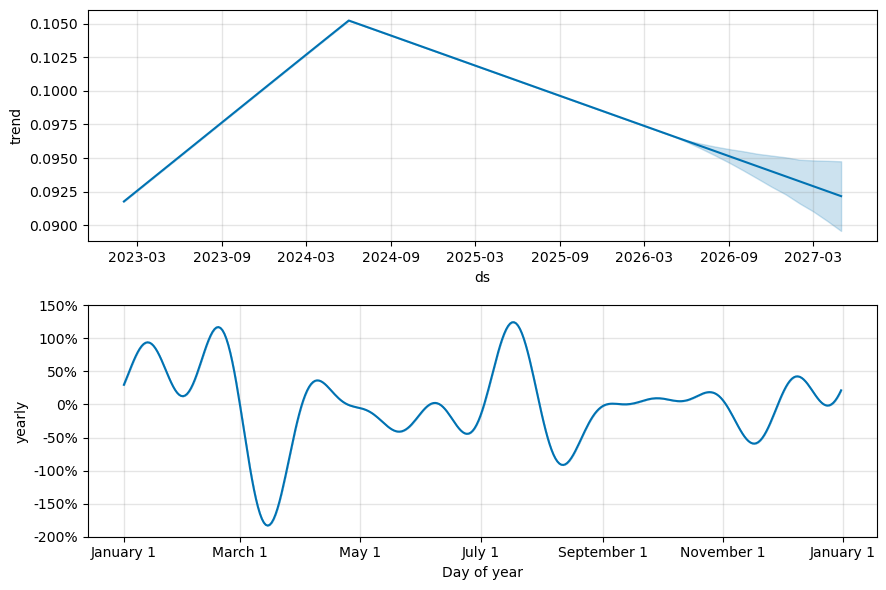

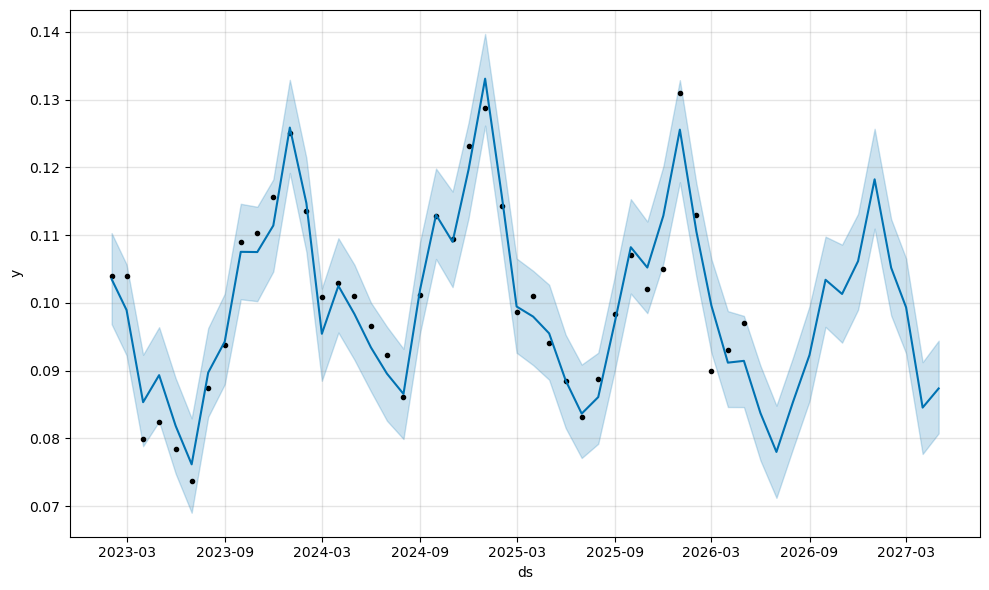

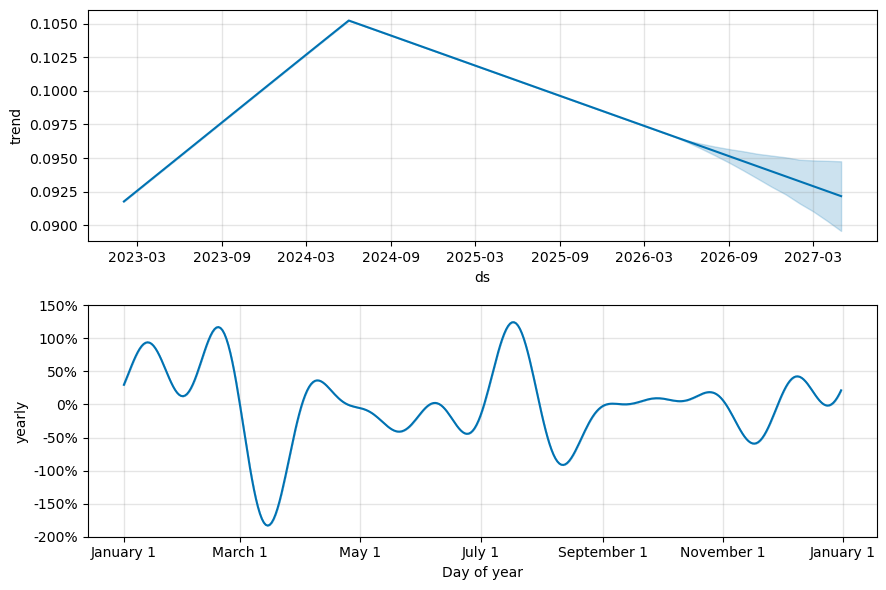

In [40]:
# Plotting the model
model2.plot(forecast)
model2.plot_components(forecast)

In [42]:
df_cv = cross_validation(
    model2,
    initial='730 days',    # train on first 2 years
    period='90 days',      # re-evaluate every 3 months
    horizon='180 days',    # test how well it predicts 6 months ahead
    parallel='processes'
)

df_perf = performance_metrics(df_cv)

print(f"MAPE: {df_perf['mape'].mean()*100:.1f}%")
print(f"MAE:  {df_perf['mae'].mean():,.0f} attendances")

MAPE: 4.6%
MAE:  0 attendances


In [71]:
# Linear Regression to model % of patients waiting >12 hours
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Identify the features
X = df[['total_attendances','admitted_attendances']]
y = df['pct_12hr']

#Train/test split
train_size = int(len(df) * 0.7)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

#Model Fitting
l_model = LinearRegression()
l_model.fit(X_train, y_train)

#model prediction
y_pred = l_model.predict(X_test)

#Model Evaluation
MAE = mean_absolute_error(y_test,y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))

print('Mean absolute error:',MAE)
print('Mean squared error:', RMSE)

#Interpretation of coefficients and operational insights  
print("Coefficients:",l_model.coef_)
print("Intercept:",l_model.intercept_)

Mean absolute error: 0.02229837483107523
Mean squared error: 0.024918326042983215
Coefficients: [-1.08840017e-07  4.78036785e-07]
Intercept: 0.09371020458657593


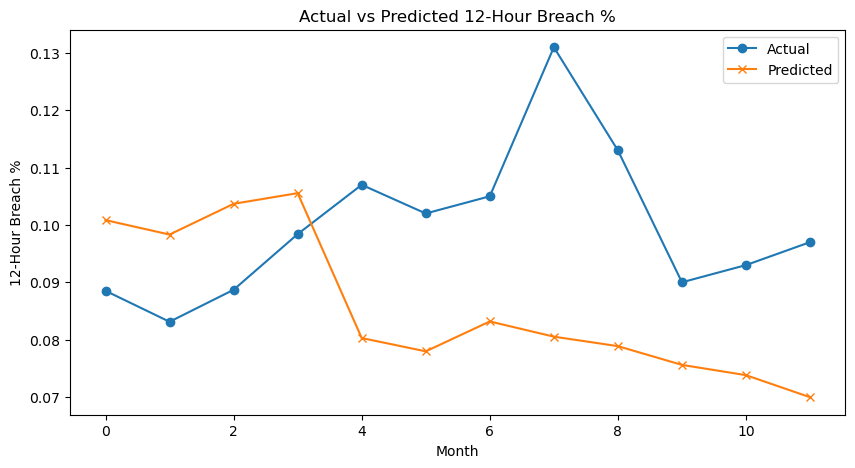

In [72]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')
plt.title("Actual vs Predicted 12‑Hour Breach %")
plt.xlabel("Month")
plt.ylabel("12‑Hour Breach %")
plt.legend()
plt.show()